In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f_oneway
import seaborn as sb

**IMPORTING DATA**

In [2]:
data1=pd.read_csv("H:\\DATA_ANALYTICS\\Projects\\Tuberculosis\\raw_data\\cases.csv")
c=pd.DataFrame(data1)
data2=pd.read_csv("H:\\DATA_ANALYTICS\\Projects\\Tuberculosis\\raw_data\\treatments.csv")
t=pd.DataFrame(data2)
data3=pd.read_csv("H:\\DATA_ANALYTICS\\Projects\\Tuberculosis\\raw_data\\demo_outcomes.csv")
d=pd.DataFrame(data3)

**DELETING IRRELEVENT COULMNS IN THE DATASETS**

In [3]:
c=c[['country','iso3','g_whoregion','year','c_newinc','new_sp','new_sn','new_ep','ret_rel']]
t=t[['country','iso3','g_whoregion','year','newrel_coh','newrel_succ','newrel_fail','newrel_died','newrel_lost','c_new_tsr']]
d=d[['country','iso3','g_whoregion','year','age_group','sex','coh','succ','fail','died','lost','tsr']]

Deleting the records before 2013 as our analysis focuses on the timespan of 12 years (2013-2024)

In [4]:
c=c[c['year']>2012]
t=t[t['year']>2012]
d=d[d['year']>2012]

**CLEANING 'CASES' TABLE**

Handling Nulls

In [5]:
(c.isnull().sum() / len(c)) * 100

country          0.000000
iso3             0.000000
g_whoregion      0.000000
year             0.000000
c_newinc         3.255814
new_sp         100.000000
new_sn         100.000000
new_ep           3.604651
ret_rel        100.000000
dtype: float64

In [6]:
# dropping columns with 100% null values
c=c.drop(columns=['ret_rel','new_sp','new_sn'])

In [7]:
#dropping null records in column c_newinc
c = c.dropna(subset=['c_newinc'])

In [8]:
(c.isnull().sum() / len(c)) * 100

country        0.000000
iso3           0.000000
g_whoregion    0.000000
year           0.000000
c_newinc       0.000000
new_ep         0.360577
dtype: float64

Checking Inconsistencies in the Data

In [9]:
c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2496 entries, 33 to 9566
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      2496 non-null   object 
 1   iso3         2496 non-null   object 
 2   g_whoregion  2496 non-null   object 
 3   year         2496 non-null   int64  
 4   c_newinc     2496 non-null   float64
 5   new_ep       2487 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 136.5+ KB


In [10]:
c['c_newinc'] = c['c_newinc'].astype('Int64')
c['new_ep'] = c['new_ep'].astype('Int64')

In [11]:
c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2496 entries, 33 to 9566
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   country      2496 non-null   object
 1   iso3         2496 non-null   object
 2   g_whoregion  2496 non-null   object
 3   year         2496 non-null   int64 
 4   c_newinc     2496 non-null   Int64 
 5   new_ep       2487 non-null   Int64 
dtypes: Int64(2), int64(1), object(3)
memory usage: 141.4+ KB


In [12]:
c.head(12)

,country,iso3,g_whoregion,year,c_newinc,new_ep
33,Afghanistan,AFG,EMR,2013,30507,7056
34,Afghanistan,AFG,EMR,2014,31746,7227
35,Afghanistan,AFG,EMR,2015,35878,8976
36,Afghanistan,AFG,EMR,2016,41954,10738
37,Afghanistan,AFG,EMR,2017,46640,12329
38,Afghanistan,AFG,EMR,2018,48420,13646
39,Afghanistan,AFG,EMR,2019,52438,13395
40,Afghanistan,AFG,EMR,2020,45818,11401
41,Afghanistan,AFG,EMR,2021,50324,12699
42,Afghanistan,AFG,EMR,2022,51749,13702


In [13]:
c = c.reset_index(drop=True)

In [14]:
c.head(5)

,country,iso3,g_whoregion,year,c_newinc,new_ep
0,Afghanistan,AFG,EMR,2013,30507,7056
1,Afghanistan,AFG,EMR,2014,31746,7227
2,Afghanistan,AFG,EMR,2015,35878,8976
3,Afghanistan,AFG,EMR,2016,41954,10738
4,Afghanistan,AFG,EMR,2017,46640,12329


**CLEANING 'TREATMENTS' TABLE**

In [15]:
((t.isnull().sum())/len(t))*100

country         0.000000
iso3            0.000000
g_whoregion     0.000000
year            0.000000
newrel_coh      9.217759
newrel_succ     9.725159
newrel_fail    11.035941
newrel_died    10.317125
newrel_lost    10.655391
c_new_tsr      11.670190
dtype: float64

In [16]:
t=t.dropna(subset=['newrel_coh'])

In [17]:
((t.isnull().sum())/len(t))*100

country        0.000000
iso3           0.000000
g_whoregion    0.000000
year           0.000000
newrel_coh     0.000000
newrel_succ    0.558919
newrel_fail    2.002795
newrel_died    1.210992
newrel_lost    1.583605
c_new_tsr      2.701444
dtype: float64

In [18]:
t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2147 entries, 19 to 6398
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      2147 non-null   object 
 1   iso3         2147 non-null   object 
 2   g_whoregion  2147 non-null   object 
 3   year         2147 non-null   int64  
 4   newrel_coh   2147 non-null   float64
 5   newrel_succ  2135 non-null   float64
 6   newrel_fail  2104 non-null   float64
 7   newrel_died  2121 non-null   float64
 8   newrel_lost  2113 non-null   float64
 9   c_new_tsr    2089 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 184.5+ KB


In [19]:
t['newrel_coh'] = t['newrel_coh'].astype('Int64')
t['newrel_succ'] = t['newrel_succ'].astype('Int64')
t['newrel_fail'] = t['newrel_fail'].astype('Int64')
t['newrel_died'] = t['newrel_died'].astype('Int64')
t['newrel_lost'] = t['newrel_lost'].astype('Int64')

In [20]:
t = t.reset_index(drop=True)

In [21]:
t.head(5)

,country,iso3,g_whoregion,year,newrel_coh,newrel_succ,newrel_fail,newrel_died,newrel_lost,c_new_tsr
0,Afghanistan,AFG,EMR,2013,30507,26733,172,435,638,88.0
1,Afghanistan,AFG,EMR,2014,31746,27553,204,405,712,87.0
2,Afghanistan,AFG,EMR,2015,36042,31631,211,542,872,88.0
3,Afghanistan,AFG,EMR,2016,40287,37418,295,460,723,93.0
4,Afghanistan,AFG,EMR,2017,46640,42288,237,700,903,91.0


**CLEANING 'DEMOGRAPHIC OUTCOMES' TABLE**

In [22]:
d.head()

,country,iso3,g_whoregion,year,age_group,sex,coh,succ,fail,died,lost,tsr
0,Afghanistan,AFG,EMR,2018,0-14,a,10461,10027.0,NaN,NaN,NaN,96.0
4,Albania,ALB,EUR,2013,0-14,a,19,18.0,0.0,0.0,1.0,95.0
5,Albania,ALB,EUR,2014,0-14,a,21,20.0,0.0,0.0,0.0,95.0
6,Albania,ALB,EUR,2015,0-14,a,11,10.0,0.0,0.0,0.0,91.0
7,Albania,ALB,EUR,2016,0-14,a,13,11.0,0.0,0.0,1.0,85.0


In [23]:
((d.isnull().sum())/len(d))*100

country         0.000000
iso3            0.000000
g_whoregion     0.000000
year            0.000000
age_group       0.000000
sex             0.000000
coh             0.000000
succ            1.215395
fail           33.220797
died           33.018231
lost           32.950709
tsr             8.440243
dtype: float64

In [24]:
d['year'].unique()

array([2018, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021, 2022, 2023])

In [25]:
d['age_group'].unique()

array(['0-14', 'a'], dtype=object)

In [26]:
d['sex'].unique()

array(['a', 'f', 'm'], dtype=object)

In [27]:
d.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1481 entries, 0 to 1606
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      1481 non-null   object 
 1   iso3         1481 non-null   object 
 2   g_whoregion  1481 non-null   object 
 3   year         1481 non-null   int64  
 4   age_group    1481 non-null   object 
 5   sex          1481 non-null   object 
 6   coh          1481 non-null   int64  
 7   succ         1463 non-null   float64
 8   fail         989 non-null    float64
 9   died         992 non-null    float64
 10  lost         993 non-null    float64
 11  tsr          1356 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 150.4+ KB


In [28]:
d['succ']=d['succ'].astype('Int64')
d['fail']=d['fail'].astype('Int64')
d['died']=d['died'].astype('Int64')
d['lost']=d['lost'].astype('Int64')

**1)	Analyze global and regional distribution in TB incidence from 2013–2024.**

In [29]:
c.head()

,country,iso3,g_whoregion,year,c_newinc,new_ep
0,Afghanistan,AFG,EMR,2013,30507,7056
1,Afghanistan,AFG,EMR,2014,31746,7227
2,Afghanistan,AFG,EMR,2015,35878,8976
3,Afghanistan,AFG,EMR,2016,41954,10738
4,Afghanistan,AFG,EMR,2017,46640,12329


In [30]:
#global trends in TB cases

gb_y=c.groupby('year')['c_newinc'].sum()
gb_y = gb_y.reset_index()
gb_y['cases_millions'] = round((gb_y['c_newinc'] / 1e6),2)
print("Global trends in TB cases : \n",gb_y.head())
print('_'*50)

#regional trends in TB cases

gb_r=c.groupby('g_whoregion')['c_newinc'].sum()
gb_r = gb_r.reset_index()
gb_r['cases_millions'] = round((gb_r['c_newinc'] / 1e6),2)
print("Regional trends in TB cases : \n",gb_r.head())

Global trends in TB cases : 
    year  c_newinc  cases_millions
0  2013   5732020            5.73
1  2014   6067033            6.07
2  2015   6160831            6.16
3  2016   6356184            6.36
4  2017   6352197            6.35
__________________________________________________
Regional trends in TB cases : 
   g_whoregion  c_newinc  cases_millions
0         AFR  17713021           17.71
1         AMR   2784927            2.78
2         EMR   6241054            6.24
3         EUR   2606493            2.61
4         SEA  29829971           29.83


In [31]:
gb_r.describe()

,c_newinc,cases_millions
count,6.0,6.0
mean,13491140.333333,13.49
std,11304921.671235,11.304896
min,2606493.0,2.61
25%,3648958.75,3.645
50%,11977037.5,11.975
75%,20756787.25,20.755
max,29829971.0,29.83


In [32]:
c['g_whoregion'].unique()

array(['EMR', 'EUR', 'AFR', 'WPR', 'AMR', 'SEA'], dtype=object)

C:\Users\intel 2018\AppData\Local\Temp\ipykernel_7936\2193967231.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.barplot(data=gb_r,x='g_whoregion',y='cases_millions',palette=gb_r['colors'].tolist())


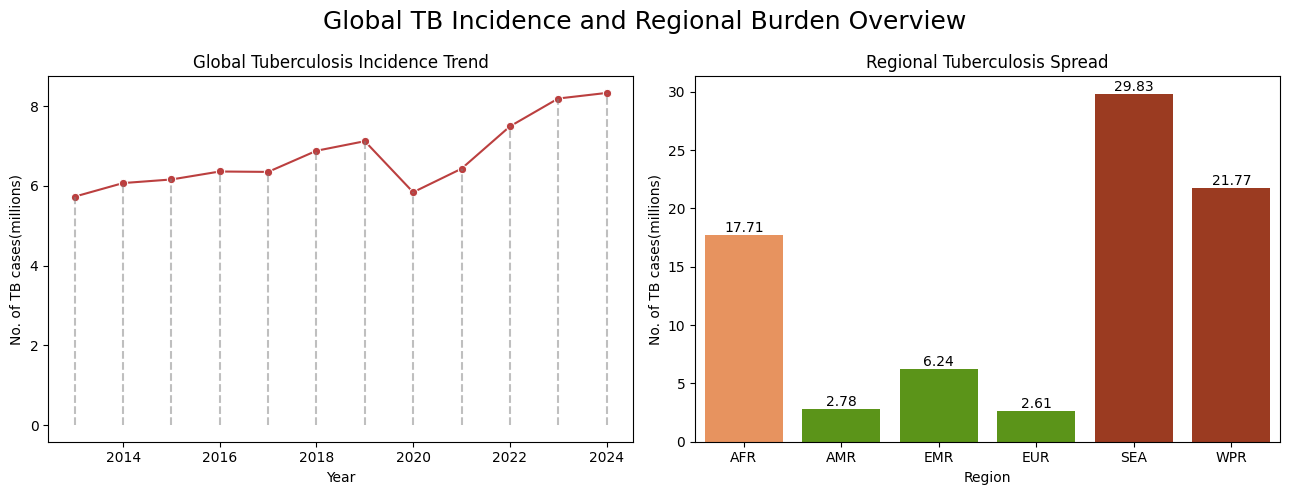

In [60]:
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.title("Global Tuberculosis Incidence Trend")
sb.lineplot(data=gb_y,x='year',y='cases_millions',color='#bb3f3f',marker='o')
plt.vlines(x=gb_y['year'],ymin=0,ymax=gb_y['cases_millions'],colors='gray',alpha=0.5,linestyle='dashed')
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Year")
plt.ylabel("No. of TB cases(millions)")

plt.subplot(1,2,2)
plt.title("Regional Tuberculosis Spread")
def burden_color(val):   #function to set the colours of the bars in the plot.
    if val >= 20:
        return '#af2f0d'   # high burden 
    elif val >= 10:
        return '#fd8d49'   # medium burden 
    else:
        return '#5ca904'   # low burden 
gb_r['colors'] = gb_r['cases_millions'].apply(burden_color)
ax=sb.barplot(data=gb_r,x='g_whoregion',y='cases_millions',palette=gb_r['colors'].tolist())
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
ax.bar_label(ax.containers[3])
ax.bar_label(ax.containers[4])
ax.bar_label(ax.containers[5])
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Region")
plt.ylabel("No. of TB cases(millions)")

plt.suptitle("Global TB Incidence and Regional Burden Overview",fontsize=18)
plt.tight_layout()
#plt.savefig("H:/DATA_ANALYTICS/Projects/Tuberculosis/charts/incidence_burden_overview.png", dpi=300, bbox_inches="tight")
plt.show()

**Key Insights**
1. Global TB incidence shows an overall increasing trend from 2013 to 2024, indicating a persistent and growing global disease burden.
2. A noticeable dip is observed around 2020, followed by a sharp rebound in subsequent years.
3. The 2020 decline is unlikely due to an actual reduction in TB cases; it more plausibly reflects under-reporting and disrupted surveillance during      the COVID-19 pandemic.
4. South-East Asia (SEA) region contributes the highest share of global TB cases, highlighting it as the primary high-burden region.
5. Western Pacific (WPR) and African (AFR) regions also show substantial case loads, though lower than SEA.
6. Regions like Europe (EUR) and the Americas (AMR) report comparatively lower TB incidence, indicating better control or lower baseline burden.
7. The strong regional disparity suggests that global TB burden is highly concentrated in specific geographic regions rather than evenly distributed.

**2)	Evaluate treatment success, failure, death, and loss-to-follow-up rates across countries and WHO regions.**

In [34]:
for df in [c, t, d]:
    df['country'] = df['country'].str.replace('Democratic Republic of the Congo', 'Congo', regex=False)

In [35]:
t.head()

,country,iso3,g_whoregion,year,newrel_coh,newrel_succ,newrel_fail,newrel_died,newrel_lost,c_new_tsr
0,Afghanistan,AFG,EMR,2013,30507,26733,172,435,638,88.0
1,Afghanistan,AFG,EMR,2014,31746,27553,204,405,712,87.0
2,Afghanistan,AFG,EMR,2015,36042,31631,211,542,872,88.0
3,Afghanistan,AFG,EMR,2016,40287,37418,295,460,723,93.0
4,Afghanistan,AFG,EMR,2017,46640,42288,237,700,903,91.0


In [36]:
t['tsr']=t['c_new_tsr']  #changing the name of the column{total success rate}
t=t.drop(columns=['c_new_tsr'])
t['tfr']=round((t['newrel_fail']/t['newrel_coh'])*100)  #treatment failure rate
t['tdr']=round((t['newrel_died']/t['newrel_coh'])*100)  #treatment death rate
t['tlr']=round((t['newrel_lost']/t['newrel_coh'])*100)  #treatment lost rate

In [37]:
#changing the places of the columns in the treatments dataframe.
t=t[['country','iso3','g_whoregion','year','newrel_coh','newrel_succ','newrel_fail','newrel_died','newrel_lost','tsr','tfr','tdr','tlr']]	

In [38]:
t.head()

,country,iso3,g_whoregion,year,newrel_coh,newrel_succ,newrel_fail,newrel_died,newrel_lost,tsr,tfr,tdr,tlr
0,Afghanistan,AFG,EMR,2013,30507,26733,172,435,638,88.0,1.0,1.0,2.0
1,Afghanistan,AFG,EMR,2014,31746,27553,204,405,712,87.0,1.0,1.0,2.0
2,Afghanistan,AFG,EMR,2015,36042,31631,211,542,872,88.0,1.0,2.0,2.0
3,Afghanistan,AFG,EMR,2016,40287,37418,295,460,723,93.0,1.0,1.0,2.0
4,Afghanistan,AFG,EMR,2017,46640,42288,237,700,903,91.0,1.0,2.0,2.0


In [39]:
#top 10 countries based on the cohort size.
top_coh = t.groupby(['country','iso3'])['newrel_coh'].sum().sort_values( ascending=False).head(10).reset_index()
top_coh

,country,iso3,newrel_coh
0,India,IND,19893753
1,China,CHN,7711154
2,Indonesia,IDN,4995191
3,Pakistan,PAK,3833046
4,Philippines,PHL,3783293
5,Bangladesh,BGD,2702962
6,South Africa,ZAF,2589589
7,Congo,COD,1882168
8,Nigeria,NGA,1675660
9,Myanmar,MMR,1318928


In [40]:
#filtering the top 10 countries based on the cohort size from the treatments table.
t_top=t[t['country'].isin(top_coh['country'])].reset_index()
t_top

,index,country,iso3,g_whoregion,year,newrel_coh,newrel_succ,newrel_fail,newrel_died,newrel_lost,tsr,tfr,tdr,tlr
0,141,Bangladesh,BGD,SEA,2013,184077,170893,822,7395,2251,93.0,0.0,4.0,1.0
1,142,Bangladesh,BGD,SEA,2014,191141,177715,1027,7252,2232,93.0,1.0,4.0,1.0
2,143,Bangladesh,BGD,SEA,2015,206907,192571,1148,7806,2084,93.0,1.0,4.0,1.0
3,144,Bangladesh,BGD,SEA,2016,222252,207832,1187,8040,1640,94.0,1.0,4.0,1.0
4,145,Bangladesh,BGD,SEA,2017,242640,227305,1030,8762,1773,94.0,0.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1784,South Africa,ZAF,AFR,2019,216725,170806,1657,15920,22452,79.0,1.0,7.0,10.0
116,1785,South Africa,ZAF,AFR,2020,166064,130318,1368,13437,17187,78.0,1.0,8.0,10.0
117,1786,South Africa,ZAF,AFR,2021,161359,127431,1186,12861,14340,79.0,1.0,8.0,9.0
118,1787,South Africa,ZAF,AFR,2022,213343,161478,1365,14626,20302,76.0,1.0,7.0,10.0


In [41]:
# mean performance rates for top cohort countries
gb_crates = (t_top.groupby('country')[['tsr','tfr','tdr','tlr']].mean().reset_index().round(2))

print("Top 10 largest cohort size countries' performance rates:")
print("_"*50)
print(gb_crates)

Top 10 largest cohort size countries' performance rates:
__________________________________________________
        country    tsr   tfr   tdr   tlr
0    Bangladesh  94.45  0.27  3.36  0.73
1         China  94.18  0.36  1.82  1.45
2         Congo  83.14  0.43  2.33  7.57
3         India  81.91  0.82  3.82  3.73
4     Indonesia  85.45   0.0  2.73  6.18
5       Myanmar  87.09  1.09  4.73  5.55
6       Nigeria  88.36  0.82  3.91  4.91
7      Pakistan  93.64  0.45  1.73  2.64
8   Philippines  85.64  0.18  2.09  5.18
9  South Africa  77.27  0.45  6.91  8.73


In [42]:
#performance rates of the who regions
gb_rrates = (t.groupby('g_whoregion')[['tsr','tfr','tdr','tlr']].mean().reset_index().round(2))
print("Regional performance rates: ")
print("_"*50)
print(gb_rrates)

Regional performance rates: 
__________________________________________________
  g_whoregion    tsr   tfr   tdr   tlr
0         AFR  81.90  1.01  5.99  6.47
1         AMR  75.50   NaN   NaN   NaN
2         EMR  83.07  0.59  3.42  6.14
3         EUR  73.51   NaN   NaN   NaN
4         SEA  85.93  1.33  4.51  3.44
5         WPR  81.49   NaN   NaN   NaN


C:\Users\intel 2018\AppData\Local\Temp\ipykernel_7936\1048768111.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=gb_crates, x='country', y='tsr', palette=gb_crates['colors'].tolist(), ax=ax1)
C:\Users\intel 2018\AppData\Local\Temp\ipykernel_7936\1048768111.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=gb_rrates, x='g_whoregion', y='tsr', palette=gb_rrates['colors'].tolist(), ax=ax3)


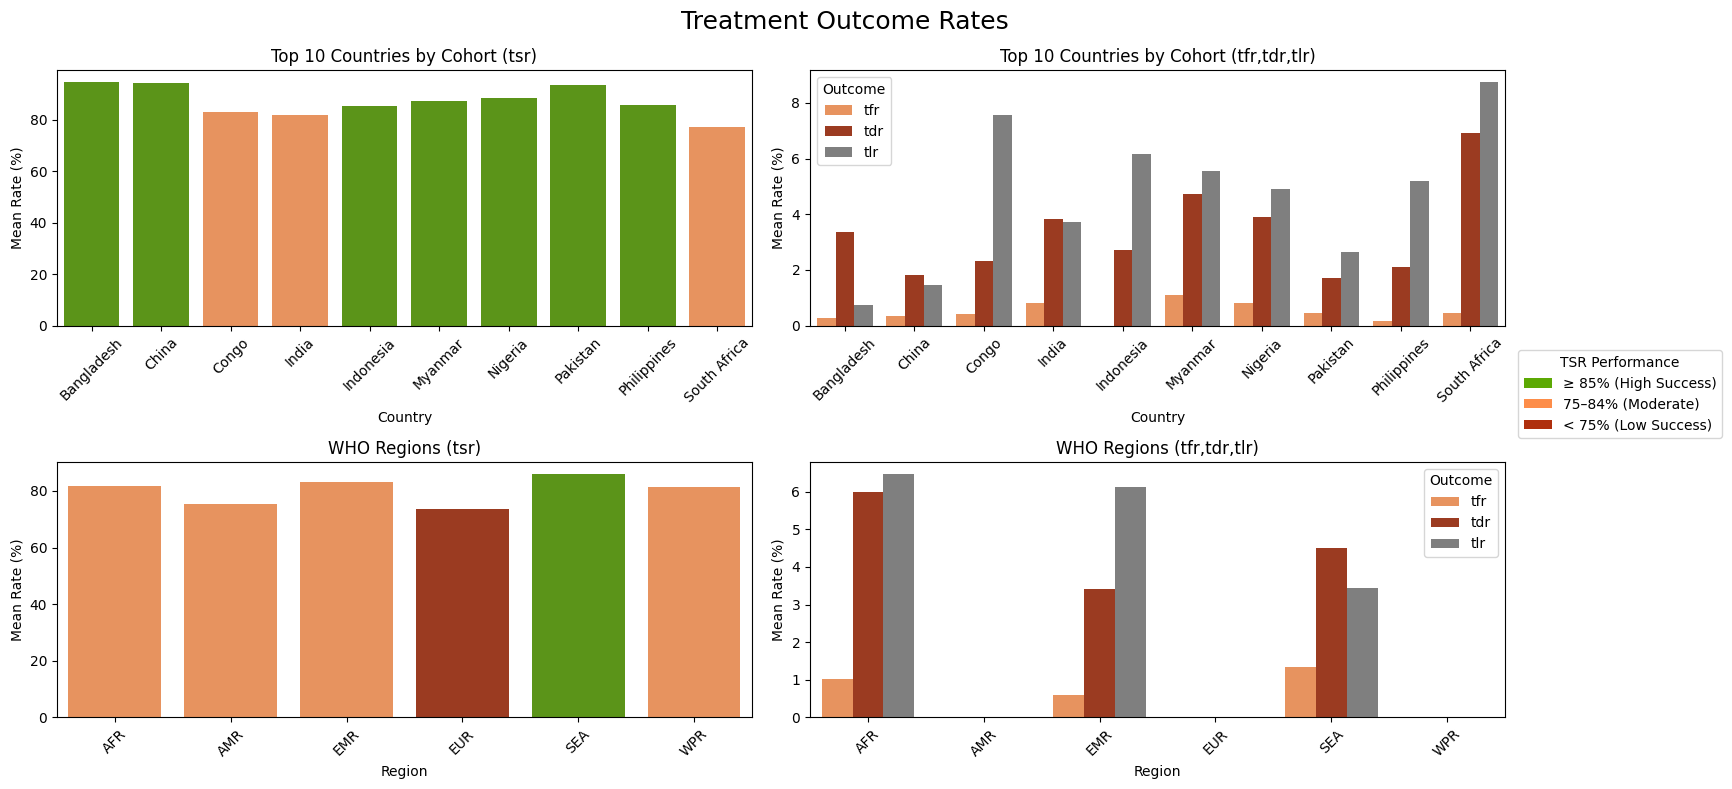

In [61]:
plt.figure(figsize=(17,8))

def burden_color(val):   #function to set the colours of the bars in the plot.
    if val >= 85:
        return '#5ca904'   
    elif 75 <= val < 85:
        return '#fd8d49'   
    else:
        return '#af2f0d'   
gb_crates['colors'] = gb_crates['tsr'].apply(burden_color)

ax1 = plt.subplot(2,2,1)
ax1.set_title("Top 10 Countries by Cohort (tsr)")
sb.barplot(data=gb_crates, x='country', y='tsr', palette=gb_crates['colors'].tolist(), ax=ax1)
ax1.set_xlabel("Country")
ax1.set_ylabel("Mean Rate (%)")
ax1.tick_params(axis='x', rotation=45)

gb_rrates['colors'] = gb_rrates['tsr'].apply(burden_color)

ax3 = plt.subplot(2,2,3)
ax3.set_title("WHO Regions (tsr)")
sb.barplot(data=gb_rrates, x='g_whoregion', y='tsr', palette=gb_rrates['colors'].tolist(), ax=ax3)
ax3.set_xlabel("Region")
ax3.set_ylabel("Mean Rate (%)")
ax3.tick_params(axis='x', rotation=45)

ax2 = plt.subplot(2,2,2)
ax2.set_title("Top 10 Countries by Cohort (tfr,tdr,tlr)")
crates_melt = gb_crates.melt(id_vars='country', value_vars=['tfr','tdr','tlr'],
                             var_name='Outcome', value_name='Rate')
colors={'tfr':'#fd8d49','tdr':'#af2f0d','tlr':'#7f7f7f'}
sb.barplot(data=crates_melt, x='country', y='Rate', hue='Outcome', palette=colors, ax=ax2)
ax2.set_xlabel("Country")
ax2.set_ylabel("Mean Rate (%)")
ax2.tick_params(axis='x', rotation=45)

ax4 = plt.subplot(2,2,4)
ax4.set_title('WHO Regions (tfr,tdr,tlr)')
rrates_melt = gb_rrates.melt(id_vars='g_whoregion', value_vars=['tfr','tdr','tlr'],
                             var_name='Outcome', value_name='Rate')
sb.barplot(data=rrates_melt, x='g_whoregion', y='Rate', hue='Outcome', palette=colors, ax=ax4)
ax4.set_xlabel("Region")
ax4.set_ylabel("Mean Rate (%)")
ax4.tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5ca904', label='≥ 85% (High Success)'),
    Patch(facecolor='#fd8d49', label='75–84% (Moderate)'),
    Patch(facecolor='#af2f0d', label='< 75% (Low Success)')
]

fig = plt.gcf()
fig.legend(handles=legend_elements, title='TSR Performance',
           loc='center right', bbox_to_anchor=(1.02, 0.5))

plt.suptitle("Treatment Outcome Rates", fontsize=18)
plt.tight_layout(rect=[0, 0, 0.9, 1])
#plt.savefig("H:/DATA_ANALYTICS/Projects/Tuberculosis/charts/outcome_rates.png", dpi=300, bbox_inches="tight")
plt.show()

**Key Insights**

1. Most of the top 10 countries (e.g., Bangladesh, China, Pakistan, Nigeria) have TSR ≥ 85%, indicating strong treatment success and effective TB         control programs.
2. Countries like India and Congo fall in the 75–84% range, suggesting scope for improvement in treatment adherence and healthcare delivery systems.
3. The South-East Asia (SEA) region shows the highest TSR, while the European region (EUR) records comparatively lower success rates, highlighting        disparities in regional TB management efficiency.
4. Across both countries and regions, Treatment Failure Rate (TFR) and Death Rate (TDR) remain significantly lower than TSR, indicating overall           effectiveness of treatment regimens.
5. Some countries (e.g., South Africa and Congo) show relatively higher TLR, implying patient retention and treatment completion remain major             challenges.
6. The AFR region has comparatively higher TDR than other regions, reflecting gaps in timely diagnosis, treatment access, and comorbidity management      (like HIV-TB co-infection).
7. Most WHO regions maintain TSR above 75%, suggesting that global TB treatment programs are broadly effective despite regional healthcare                inequalities.
8. Some WHO regions contain null or missing values in outcome rates, suggesting incomplete reporting or data gaps that may slightly bias regional         comparisons and should be interpreted with caution.

**3)	Examine the association between TB burden (incidence) and treatment success rates.**

In [44]:
c.head()

,country,iso3,g_whoregion,year,c_newinc,new_ep
0,Afghanistan,AFG,EMR,2013,30507,7056
1,Afghanistan,AFG,EMR,2014,31746,7227
2,Afghanistan,AFG,EMR,2015,35878,8976
3,Afghanistan,AFG,EMR,2016,41954,10738
4,Afghanistan,AFG,EMR,2017,46640,12329


In [45]:
t.head()

,country,iso3,g_whoregion,year,newrel_coh,newrel_succ,newrel_fail,newrel_died,newrel_lost,tsr,tfr,tdr,tlr
0,Afghanistan,AFG,EMR,2013,30507,26733,172,435,638,88.0,1.0,1.0,2.0
1,Afghanistan,AFG,EMR,2014,31746,27553,204,405,712,87.0,1.0,1.0,2.0
2,Afghanistan,AFG,EMR,2015,36042,31631,211,542,872,88.0,1.0,2.0,2.0
3,Afghanistan,AFG,EMR,2016,40287,37418,295,460,723,93.0,1.0,1.0,2.0
4,Afghanistan,AFG,EMR,2017,46640,42288,237,700,903,91.0,1.0,2.0,2.0


In [46]:
#creating a merged data frame of the cases and the treatments table.
c_df= c[['country','iso3','g_whoregion','year','c_newinc']]
t_df = t[['country','iso3','year','tsr']]
merged_df = pd.merge(c_df,t_df,on=['country','iso3','year'],how= 'inner')
merged_df.head(10)

,country,iso3,g_whoregion,year,c_newinc,tsr
0,Afghanistan,AFG,EMR,2013,30507,88.0
1,Afghanistan,AFG,EMR,2014,31746,87.0
2,Afghanistan,AFG,EMR,2015,35878,88.0
3,Afghanistan,AFG,EMR,2016,41954,93.0
4,Afghanistan,AFG,EMR,2017,46640,91.0
5,Afghanistan,AFG,EMR,2018,48420,91.0
6,Afghanistan,AFG,EMR,2019,52438,91.0
7,Afghanistan,AFG,EMR,2020,45818,95.0
8,Afghanistan,AFG,EMR,2021,50324,93.0
9,Afghanistan,AFG,EMR,2022,51749,95.0


In [47]:
#dropping nulls in the columns tsr and c_newinc
merged_df = merged_df.dropna(subset=['c_newinc', 'tsr'])

In [48]:
merged_df.describe()

,year,c_newinc,tsr
count,2074.000000,2074.0,2074.000000
mean,2017.948409,34838.874156,78.984571
std,3.133120,155875.393199,15.918532
min,2013.000000,0.0,0.000000
25%,2015.000000,295.5,74.000000
50%,2018.000000,2737.5,83.000000
75%,2021.000000,13182.0,88.000000
max,2023.000000,2382714.0,100.000000


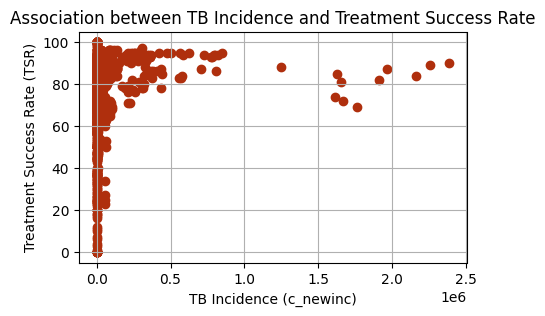

In [62]:
#visual association
plt.figure(figsize=(5,3))
plt.scatter(merged_df['c_newinc'], merged_df['tsr'],color='#af2f0d')
plt.xlabel('TB Incidence (c_newinc)')
plt.ylabel('Treatment Success Rate (TSR)')
plt.title('Association between TB Incidence and Treatment Success Rate')
plt.grid(True)
#plt.savefig("H:/DATA_ANALYTICS/Projects/Tuberculosis/charts/tb_vs_tsr.png", dpi=300, bbox_inches="tight")
plt.show()


In [50]:
#checking correlation
corr = merged_df['c_newinc'].corr(merged_df['tsr'])
print("Correlation between TB Incidence and TSR:", round(corr,1))

Correlation between TB Incidence and TSR: 0.1


**Key Insights**
1. Very weak positive association (r = 0.1) this basically means TB incidence and treatment success rate are almost unrelated. As incidence increases,    TSR doesn’t consistently increase or decrease. Statistically, this is near-no linear relationship.
2. Most countries sit in the low-incidence region, but TSR ranges wildly from very low to very high. So low burden doesn’t guarantee good treatment       outcomes.
3. A few countries with very high TB incidence still maintain TSR around 80–90%. That tells strong treatment programs can exist even under heavy          disease burden.
4. Reducing TB incidence won’t automatically improve treatment success. We need focused interventions: better diagnostics, adherence monitoring, drug     supply stability, and healthcare infrastructure.

**4)	Assess demographic variation in treatment outcomes by age group and sex, acknowledging aggregated reporting (“a” category).**

In [51]:
d.head()

,country,iso3,g_whoregion,year,age_group,sex,coh,succ,fail,died,lost,tsr
0,Afghanistan,AFG,EMR,2018,0-14,a,10461,10027,<NA>,<NA>,<NA>,96.0
4,Albania,ALB,EUR,2013,0-14,a,19,18,0,0,1,95.0
5,Albania,ALB,EUR,2014,0-14,a,21,20,0,0,0,95.0
6,Albania,ALB,EUR,2015,0-14,a,11,10,0,0,0,91.0
7,Albania,ALB,EUR,2016,0-14,a,13,11,0,0,1,85.0


In [52]:
gb_demo= d.groupby(['age_group','sex'])['tsr'].mean().reset_index(name='mean_tsr')
gb_demo

,age_group,sex,mean_tsr
0,0-14,a,83.561355
1,a,f,85.969697
2,a,m,84.151515


In [53]:
d['category'] = d.apply(lambda row:
                        'Children (0-14)' if row['age_group']=='0-14' and row['sex']=='a'
                        else 'Female (All Ages)' if row['age_group']=='a' and row['sex']=='f'
                        else 'Male (All Ages)' if row['age_group']=='a' and row['sex']=='m'
                        else 'Other', axis=1)

In [54]:
gb_c=d.groupby('category')['tsr'].mean().reset_index(name = 'mean_tsr')
gb_c

,category,mean_tsr
0,Children (0-14),83.561355
1,Female (All Ages),85.969697
2,Male (All Ages),84.151515


C:\Users\intel 2018\AppData\Local\Temp\ipykernel_7936\1997614345.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sb.barplot(data=gb_c, x='category', y='mean_tsr', palette=['#af2f0d','#5ca904','#fd8d49'])


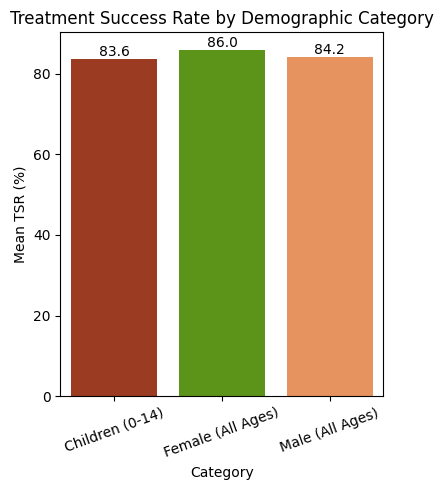

In [63]:
plt.figure(figsize=(4,5))
ax=sb.barplot(data=gb_c, x='category', y='mean_tsr', palette=['#af2f0d','#5ca904','#fd8d49'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
plt.title("Treatment Success Rate by Demographic Category")
plt.xlabel("Category")
plt.ylabel("Mean TSR (%)")
plt.xticks(rotation=20)
plt.tight_layout()
#plt.savefig("H:/DATA_ANALYTICS/Projects/Tuberculosis/charts/tsr_demo.png", dpi=300, bbox_inches="tight")
plt.show()

**Key Insights**
1. Treatment success rates are high across all demographic categories, consistently above 80%, indicating generally effective TB treatment outcomes       irrespective of age or sex.
2. Females (all ages) exhibit the highest mean TSR (~86%), suggesting slightly better treatment adherence or healthcare engagement compared to other      groups.
3. Children (0–14) show a slightly lower TSR (~83.6%) than adults, which may reflect challenges in pediatric TB diagnosis, treatment monitoring, or       case complexity.
4. Males (all ages) have a marginally lower TSR (~84.2%) than females, potentially pointing toward gender-related differences in health-seeking           behavior or treatment continuity.
5. The relatively small gap between male and female TSR indicates that sex-based disparity in treatment success is present but not substantial.
6. Overall variation across demographic groups is modest, implying that treatment programs are broadly effective but could still prioritize pediatric     care and male patient adherence for incremental improvement.

**5)	Test whether treatment success rates differ significantly across regions using statistical hypothesis testing.**

In [56]:
anova_data=t[['g_whoregion','tsr']].dropna()
anova_data.head()
anova_data['g_whoregion'].value_counts()

g_whoregion
EUR    507
AFR    507
AMR    387
WPR    349
EMR    230
SEA    109
Name: count, dtype: int64

In [57]:
# create list of TSR values for each region
groups = [group['tsr'].values for name, group in anova_data.groupby('g_whoregion')]

**H$_0$ (Null Hypothesis):**
Mean treatment success rates are equal across all WHO regions.

**H$_1$ (Alternative Hypothesis):**
At least one WHO region has a different mean treatment success rate.


In [58]:
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", round(f_stat, 4))
print("p-value:", round(p_value, 6))


F-statistic: 29.4931
p-value: 0.0


Treatment success rates vary significantly across WHO regions, as indicated by a high F-statistic and an extremely low p-value (< 0.001).
This leads to rejection of the null hypothesis that all regions have equal mean TSR, confirming the presence of statistically significant regional differences.
The result suggests that variations in healthcare infrastructure, access to diagnosis and treatment, and program implementation effectiveness contribute to differing treatment outcomes across regions.
However, statistical significance does not necessarily imply large practical differences; hence, regional mean TSR values should also be examined to assess real-world impact.

In [67]:
# exporting clean tables
#c.to_csv('cases_clean.csv')
#t.to_csv('treatments_clean.csv')
#d.to_csv('demo_clean.csv')